In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import optimize, stats
from scipy.interpolate import griddata
from matplotlib import cm, colors
from itertools import product
from matplotlib.transforms import Affine2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from IPython.display import display

# Apply publication style
pubstyle = False

# Configure matplotlib
if pubstyle:
    plt.style.use('onerule.mplstyle')

datasets = ["data/insilico/markram_1997/L5TTPC_L5TTPC_params.csv",
            "data/insilico/sjostrom_hausser_2006/L23PC_L5TTPC_params.csv",
            "data/insilico/egger_1999/L23PC_L23PC_params.csv",
            "data/insilico/rodriguez_paulsen_2008/L4PC_L23PC_params.csv",
            "data/insilico/egger_1999/L4SSC_L4SSC_params.csv"]

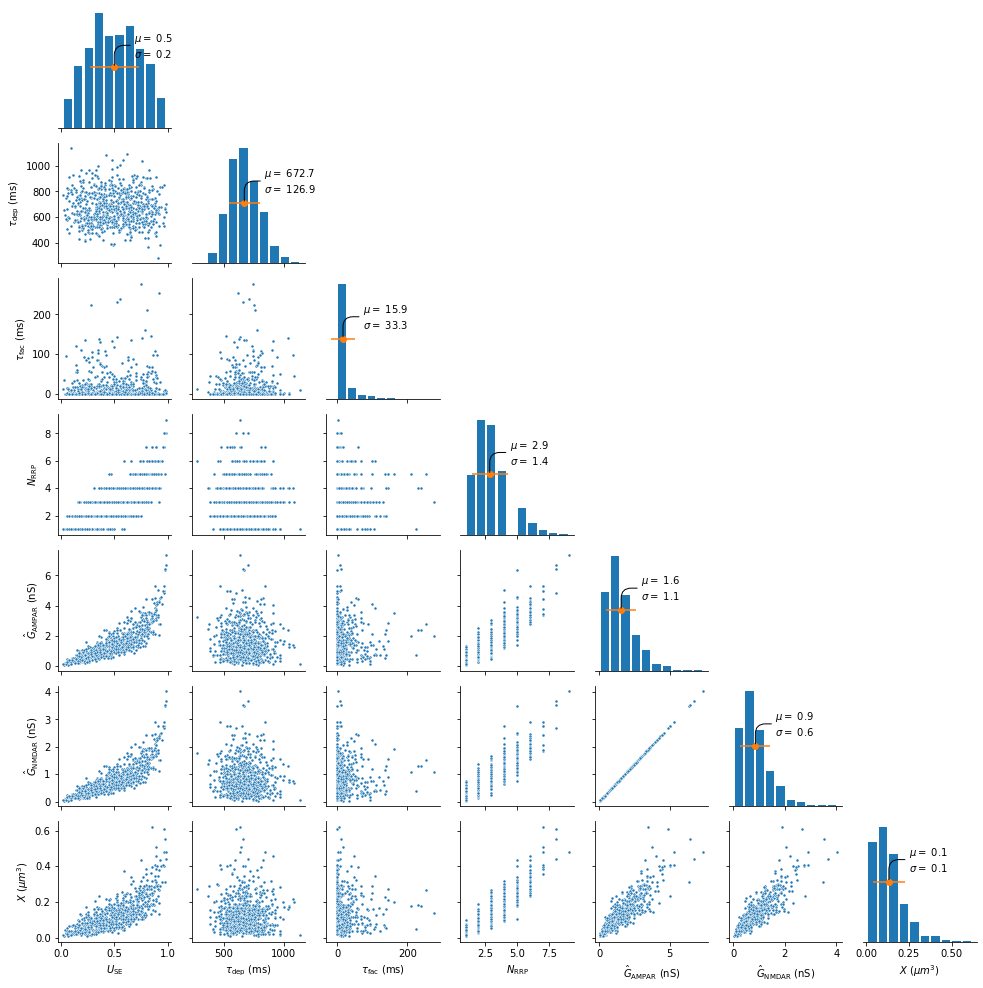

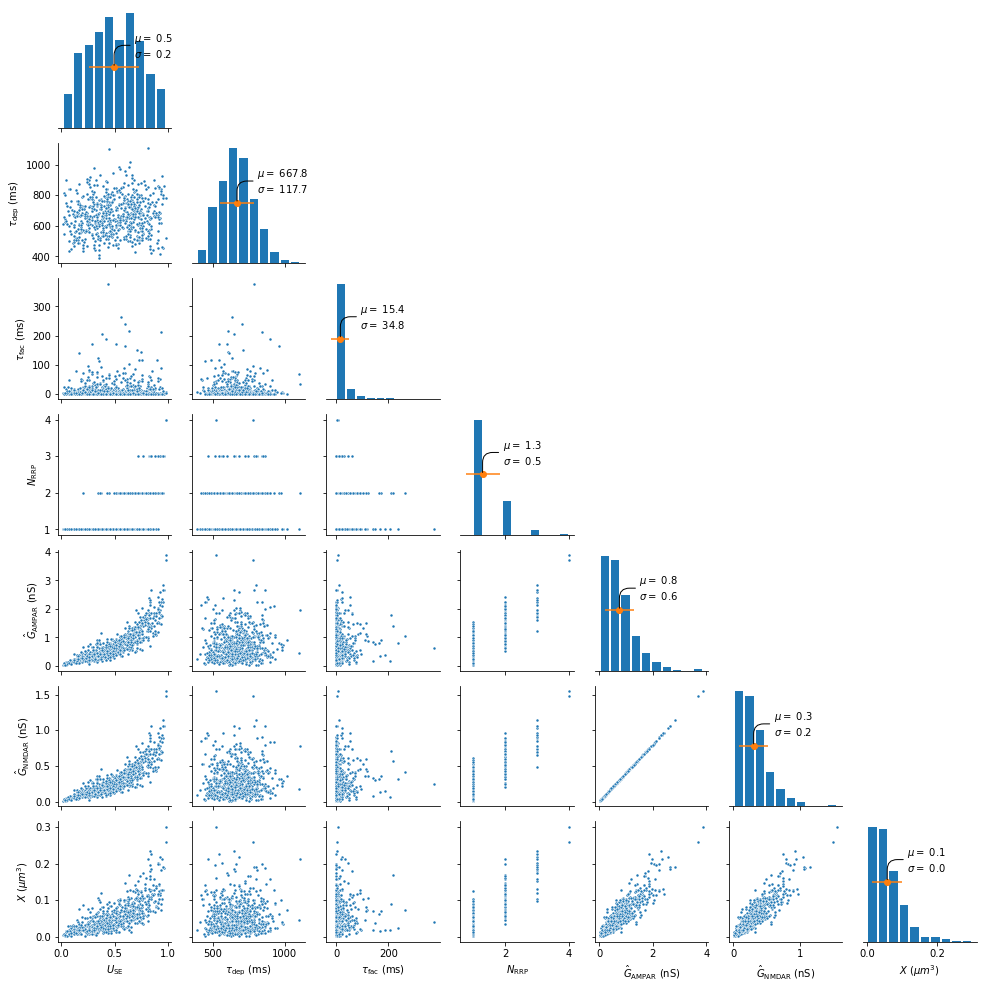

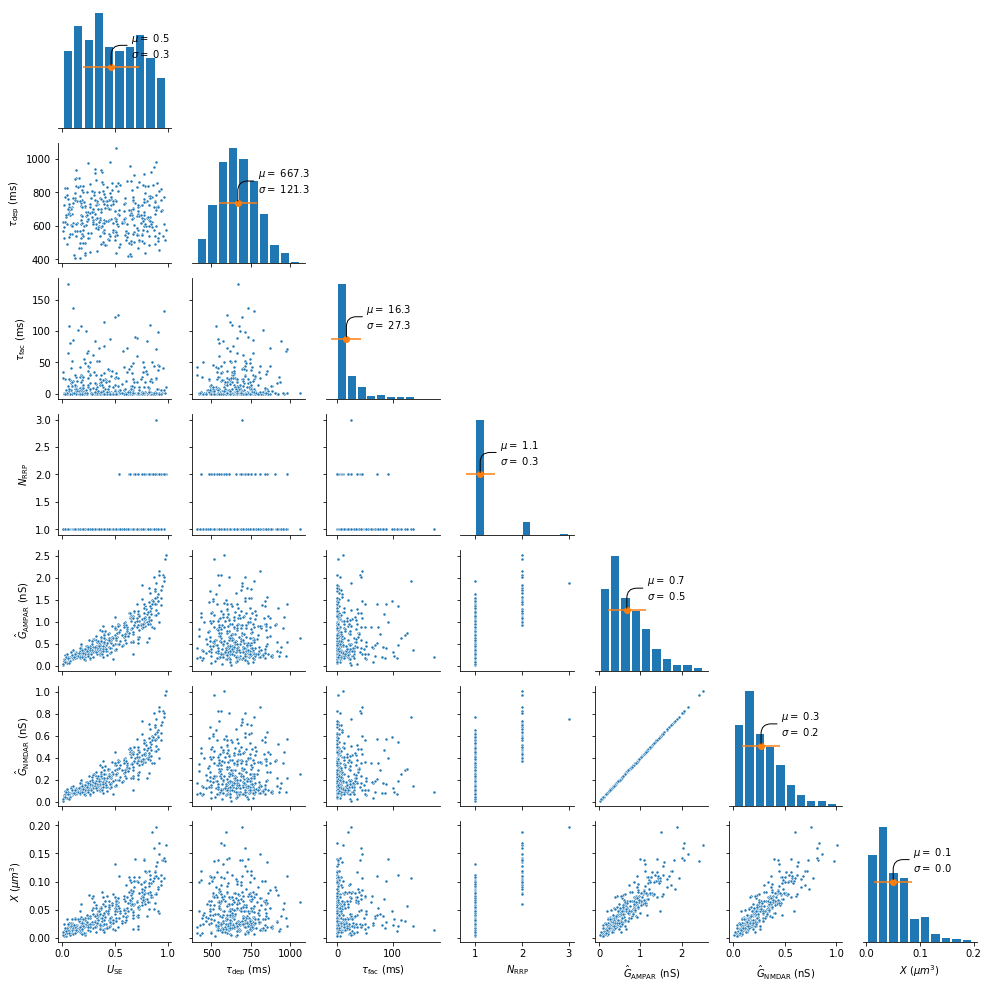

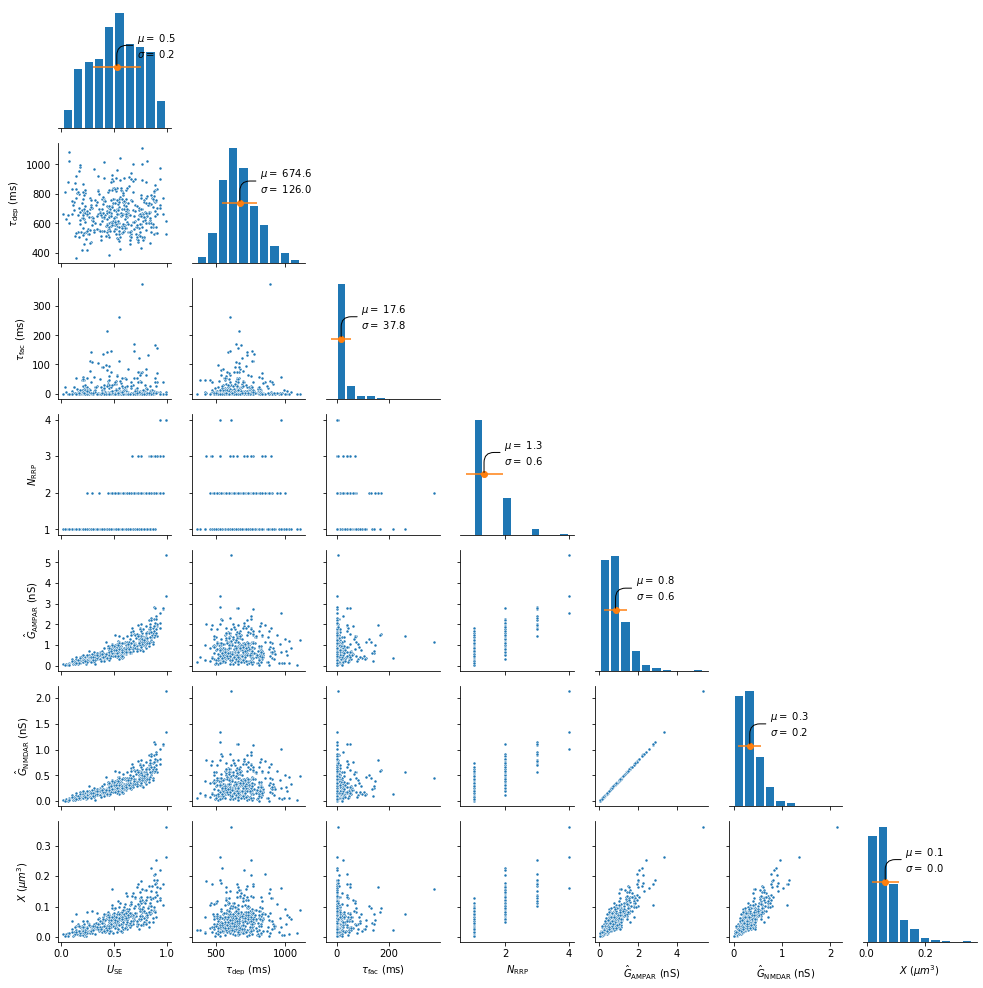

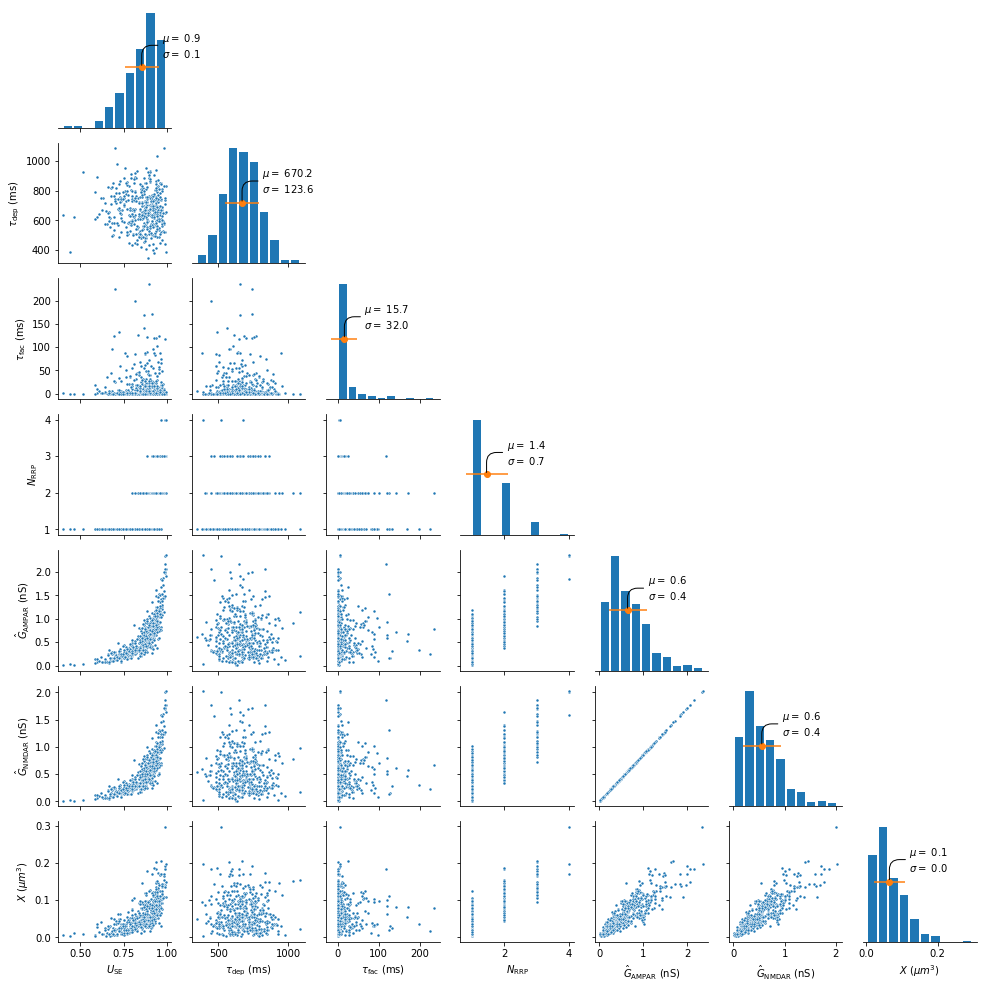

In [2]:
height = .7 if pubstyle else 2


def histerrplot(values, **kwargs):
    ax = plt.gca()
    # Plot histograms
    ax.hist(values, rwidth=0.8)
    # Plot errorbar
    ymin, ymax = ax.get_ylim()
    y = (ymin + ymax)/2
    x = np.mean(values)
    xerr = np.std(values)
    ax.errorbar(x, y, xerr=xerr, fmt="-o")
    # Annotate mean and SEM
    arrowprops = dict(arrowstyle="-", connectionstyle="angle,angleA=0,angleB=90,rad=10")
    offset = 10
    ax.annotate("$\mu =$ %.1f\n$\sigma =$ %.1f" % (x, xerr), (x, y),
                xytext=(2*offset, offset), textcoords='offset points',
                arrowprops=arrowprops)

for filename in datasets:
    label = os.path.basename(filename).split('.')[0]
    syn_params = pd.read_csv(filename, usecols=range(8), index_col=0)

    g = sns.PairGrid(syn_params, diag_sharey=False, corner=True, height=height)
    g.map_lower(sns.scatterplot, marker=".")
    g.map_diag(histerrplot)

    #g.savefig("%s.png" % label, dpi=300)